In [1]:
# 设置随机种子，使实验结果可重复
import random
import torch
import torch.nn as nn
import numpy as np

seed = 42

random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.use_deterministic_algorithms(True)
np.random.seed(seed)

In [2]:
from sklearn.datasets import load_diabetes
import pandas as pd

# 加载糖尿病数据集
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

# 创建DataFrame便于查看
feature_names = diabetes.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y


In [3]:
# 查看数据基本信息
print(f"特征字段: {diabetes.feature_names}")
print(f"样本数: {len(df)}")
print(f"特征数: {X.shape[1]}")
print(f"目标变量范围: [{y.min():.2f}, {y.max():.2f}]")
print(f"目标变量均值: {y.mean():.2f}, 标准差: {y.std():.2f}")

# 显示前5行数据
print("\n数据示例（前5行）:")
df.head()

特征字段: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
样本数: 442
特征数: 10
目标变量范围: [25.00, 346.00]
目标变量均值: 152.13, 标准差: 77.01

数据示例（前5行）:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 特征描述

所有特征均已进行标准化处理：
- `age`: 年龄
- `sex`: 性别  
- `bmi`: 身体质量指数
- `bp`: 平均血压
- `s1~s6`: 六种血清含量指标（总胆固醇、低密度脂蛋白、高密度脂蛋白、总胆固醇/高密度脂蛋白比值、血清谷丙转氨酶、血糖）

目标变量为连续值，表示糖尿病疾病进展指标（定量测量一年后的疾病进展）。

In [4]:
# 数据分割示例
from sklearn.model_selection import train_test_split

# 按4:1划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")

训练集大小: 353
测试集大小: 89


In [5]:
# 事实上数据并没有被标准化，这里重新进行标准化处理

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [6]:
# 准备 5-fold 交叉验证

from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
folds = list(kf.split(X_train))
print(f"总训练样本数: {X_train.shape[0]}")
for i, (train_idx, val_idx) in enumerate(folds):
    print(f"Fold {i+1}: 训练样本数={len(train_idx)}, 验证样本数={len(val_idx)}")

总训练样本数: 353
Fold 1: 训练样本数=282, 验证样本数=71
Fold 2: 训练样本数=282, 验证样本数=71
Fold 3: 训练样本数=282, 验证样本数=71
Fold 4: 训练样本数=283, 验证样本数=70
Fold 5: 训练样本数=283, 验证样本数=70


In [7]:
import importlib
import mlp
import matplotlib.pyplot as plt
import numpy as np

mlp = importlib.reload(mlp)

def valid_result(
        num_hidden_layers=0,
        hidden_layer_sizes=[],
        activation='none',
        lr=1e-2,
        epochs=100,
    ):

    cv_results = mlp.k_fold_cross_validate(
        X=X_train,
        y=y_train,
        model_factory_kwargs={
            'num_hidden_layers': num_hidden_layers,
            'hidden_layer_sizes': hidden_layer_sizes,
            'activation': activation,
        },
        optimizer_factory_kwargs={
            'lr': lr,
        },
        num_folds=5,
        num_epochs=epochs,
        batch_size=32,
    )

    # 聚合平均训练，验证损失
    
    train_losses = np.array([result['train_losses'] for result in cv_results]).mean(axis=0)
    val_losses = np.array([result['val_losses'] for result in cv_results]).mean(axis=0)
    best_epoch = np.argmin(val_losses)
    best_train_loss = train_losses[best_epoch]
    best_val_loss = val_losses[best_epoch]

    results = {
        'lr': lr,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_epoch': best_epoch,
        'best_train_loss': best_train_loss,
        'best_val_loss': best_val_loss,
    } 

    return results

In [8]:
baseline = valid_result(2, [16, 16], 'relu', 1e-3, 500)
baseline2 = valid_result(2, [16, 16], 'relu', 1e-2, 500)

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

In [9]:
def plot_loss_curve(model, start=0, end=-1, y_range=None):
    plt.plot(model['train_losses'][start:end], label=f'Baseline Train Loss (lr={model["lr"]:.1e})')
    plt.plot(model['val_losses'][start:end], label=f'Baseline Val Loss (lr={model["lr"]:.1e})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    if y_range is not None:
        plt.ylim(y_range)
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

In [10]:
shallow = valid_result(1, [16], 'relu', 1e-2, 500)
deep = valid_result(3, [16, 16, 16], 'relu', 1e-2, 500)

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

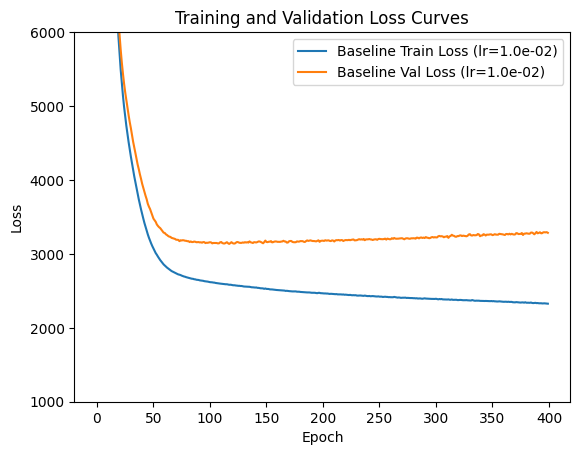

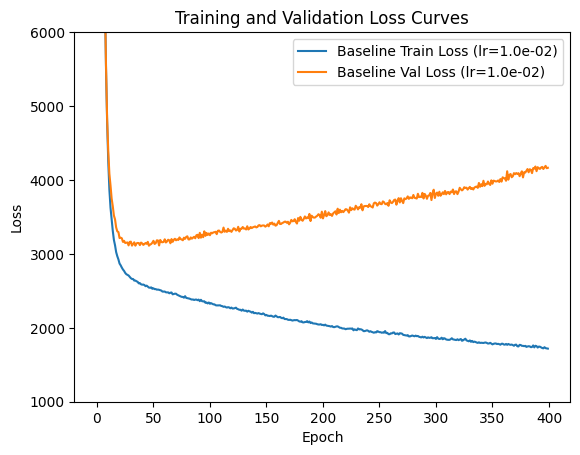

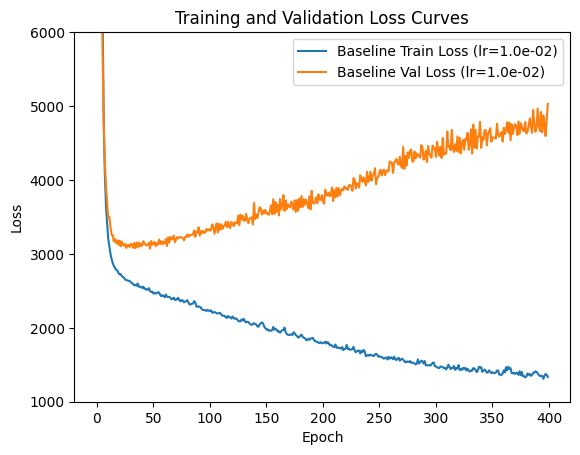

Best epochs - Shallow: 117, Baseline2: 46, Deep: 47
Best losses - Shallow: 3134.77, Baseline2: 3110.81, Deep: 3071.66


In [11]:
shallow['best_epoch'], deep['best_epoch']
plot_loss_curve(shallow, 0, 400, (1000, 6000))
plot_loss_curve(baseline2, 0, 400, (1000, 6000))
plot_loss_curve(deep, 0, 400, (1000, 6000))
print(f"Best epochs - Shallow: {shallow['best_epoch']}, Baseline2: {baseline2['best_epoch']}, Deep: {deep['best_epoch']}")
print(f"Best losses - Shallow: {shallow['best_val_loss']:.2f}, Baseline2: {baseline2['best_val_loss']:.2f}, Deep: {deep['best_val_loss']:.2f}")

In [12]:
lr1 = valid_result(2, [16, 16], 'relu', 1e-1, 500)
lr4 = valid_result(2, [16, 16], 'relu', 1e-4, 5000)
print(f"Best epochs - LR1: {lr1['best_epoch']}, LR2: {baseline2['best_epoch']}, LR3: {baseline['best_epoch']}, LR4: {lr4['best_epoch']}")
print(f"Best losses - LR1: {lr1['best_val_loss']:.2f}, LR2: {baseline2['best_val_loss']:.2f}, LR3: {baseline['best_val_loss']:.2f}, LR4: {lr4['best_val_loss']:.2f}")

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Best epochs - LR1: 21, LR2: 46, LR3: 280, LR4: 3530
Best losses - LR1: 3151.40, LR2: 3110.81, LR3: 3079.21, LR4: 3061.59


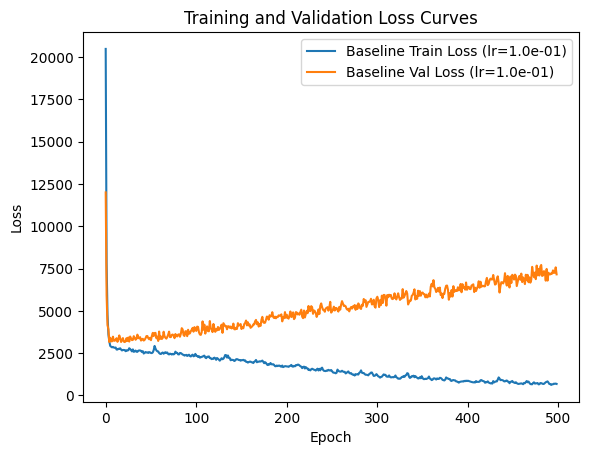

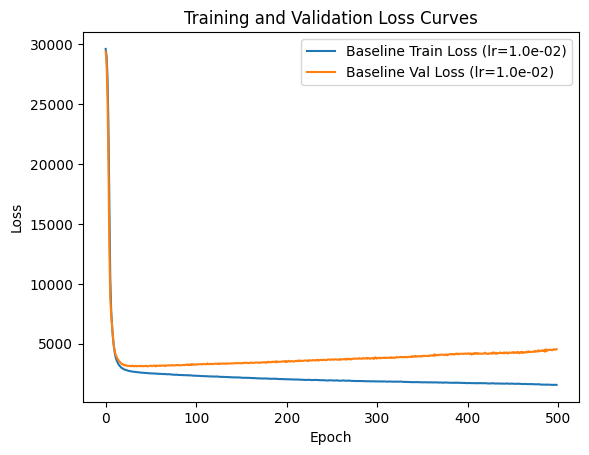

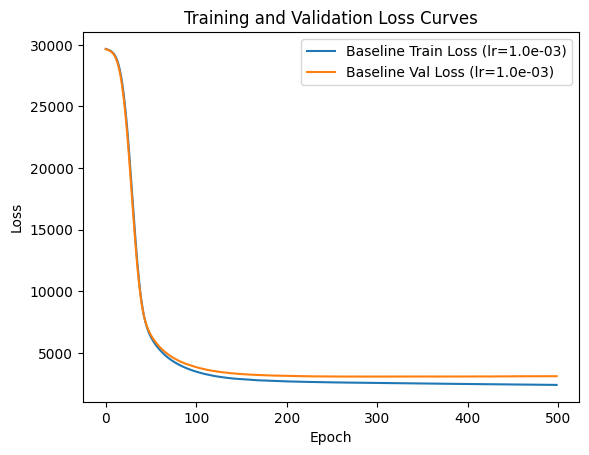

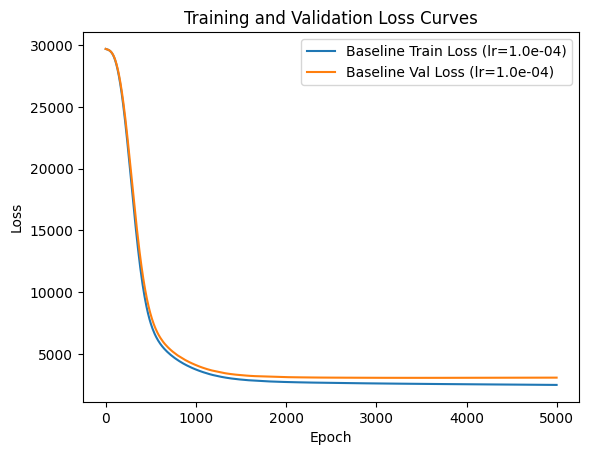

In [13]:
plot_loss_curve(lr1)
plot_loss_curve(baseline2)
plot_loss_curve(baseline)
plot_loss_curve(lr4)

In [14]:
sig = valid_result(2, [16, 16], 'sigmoid', 1e-2, 500)
tanh = valid_result(2, [16, 16], 'tanh', 1e-2, 500)
lea = valid_result(2, [16, 16], 'leaky_relu', 1e-2, 500)
swi = valid_result(2, [16, 16], 'swish', 1e-2, 500)
print(f"Best epochs - Sigmoid: {sig['best_epoch']}, Tanh: {tanh['best_epoch']}, ReLU: {baseline2['best_epoch']}, Leaky ReLU: {lea['best_epoch']}, Swish: {swi['best_epoch']}")
print(f"Best losses - Sigmoid: {sig['best_val_loss']:.2f}, Tanh: {tanh['best_val_loss']:.2f}, ReLU: {baseline2['best_val_loss']:.2f}, Leaky ReLU: {lea['best_val_loss']:.2f}, Swish: {swi['best_val_loss']:.2f}")

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Best epochs - Sigmoid: 262, Tanh: 254, ReLU: 46, Leaky ReLU: 60, Swish: 27
Best losses - Sigmoid: 4089.39, Tanh: 4026.81, ReLU: 3110.81, Leaky ReLU: 3099.71, Swish: 3282.71


In [15]:
import sys
print('Python executable:', sys.executable)

def train_full_model_for_pathology(activation='relu', lr=1e-2, epochs=500):
    model = mlp.MultiLayerPerceptron(
        in_channels=10,
        out_channels=1,
        num_hidden_layers=2,
        hidden_layer_sizes=[16, 16],
        activation=activation,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.MSELoss()
    mlp.train_model(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        X_train=X_train,
        y_train=y_train,
        num_epochs=500,
        batch_size=32,
        show_progress=False,
    )
    return model

relu_model = train_full_model_for_pathology('relu')
sig_model = train_full_model_for_pathology('sigmoid')
tanh_model = train_full_model_for_pathology('tanh')

print('=== ReLU (dead neuron, sample_threshold=0.9) ===')
relu_path = mlp.analyze_activation_pathologies(relu_model, X_train, sample_threshold=0.9, saturation_threshold=37.0)
print(f"ReLU dead neurons: {relu_path['affected_units']}/{relu_path['total_hidden_units']} ({relu_path['affected_ratio']*100:.1f}%)")
print(f"  Layer breakdown: {relu_path['layer_breakdown']}")

print('\n=== Sigmoid/Tanh vanishing check with smaller thresholds ===')
for sat_th in [37.0, 20.0, 10.0, 8.0, 6.0, 4.0]:
    sig_path = mlp.analyze_activation_pathologies(sig_model, X_train, sample_threshold=0.9, saturation_threshold=sat_th)
    tanh_path = mlp.analyze_activation_pathologies(tanh_model, X_train, sample_threshold=0.9, saturation_threshold=sat_th)
    print(f"threshold={sat_th:>4.1f} | Sigmoid: {sig_path['affected_units']}/{sig_path['total_hidden_units']} ({sig_path['affected_ratio']*100:>5.1f}%) | Tanh: {tanh_path['affected_units']}/{tanh_path['total_hidden_units']} ({tanh_path['affected_ratio']*100:>5.1f}%)")

Python executable: /opt/homebrew/anaconda3/envs/ai25/bin/python
=== ReLU (dead neuron, sample_threshold=0.9) ===
ReLU dead neurons: 4/32 (12.5%)
  Layer breakdown: [{'layer': 1, 'units': 16, 'affected_units': 0, 'affected_ratio': 0.0}, {'layer': 2, 'units': 16, 'affected_units': 4, 'affected_ratio': 0.25}]

=== Sigmoid/Tanh vanishing check with smaller thresholds ===
threshold=37.0 | Sigmoid: 0/32 (  0.0%) | Tanh: 0/32 (  0.0%)
threshold=20.0 | Sigmoid: 0/32 (  0.0%) | Tanh: 0/32 (  0.0%)
threshold=10.0 | Sigmoid: 0/32 (  0.0%) | Tanh: 0/32 (  0.0%)
threshold= 8.0 | Sigmoid: 0/32 (  0.0%) | Tanh: 0/32 (  0.0%)
threshold= 6.0 | Sigmoid: 0/32 (  0.0%) | Tanh: 0/32 (  0.0%)
threshold= 4.0 | Sigmoid: 0/32 (  0.0%) | Tanh: 0/32 (  0.0%)


In [16]:
# 平均按样本统计：
# 1) 每个样本中 ReLU 激活神经元占比（>0），再对样本取平均
# 2) 每个样本中 Sigmoid/Tanh 饱和神经元占比（|z|>=threshold），再对样本取平均

def samplewise_ratio_stats(mask_tensor):
    # mask_tensor: [num_samples, num_hidden_units], bool
    ratio_per_sample = mask_tensor.float().mean(dim=1)
    return {
        'mean': ratio_per_sample.mean().item(),
        'std': ratio_per_sample.std(unbiased=False).item(),
        'min': ratio_per_sample.min().item(),
        'max': ratio_per_sample.max().item(),
    }


def flatten_hidden_preacts(model):
    preacts = mlp.collect_hidden_preactivations(model, X_train)
    # 将两层隐藏层拼接，形成 [num_samples, total_hidden_units]
    return torch.cat(preacts, dim=1)


relu_all = flatten_hidden_preacts(relu_model)
sig_all = flatten_hidden_preacts(sig_model)
tanh_all = flatten_hidden_preacts(tanh_model)

relu_active_stats = samplewise_ratio_stats(relu_all > 0)
print('=== Average sample-wise ReLU activation ratio (z > 0) ===')
print(f"mean={relu_active_stats['mean']*100:.2f}%  std={relu_active_stats['std']*100:.2f}%  min={relu_active_stats['min']*100:.2f}%  max={relu_active_stats['max']*100:.2f}%")

for threshold in [37.0, 4.0]:
    sig_sat_stats = samplewise_ratio_stats(sig_all.abs() >= threshold)
    tanh_sat_stats = samplewise_ratio_stats(tanh_all.abs() >= threshold)

    print(f"\n=== Average sample-wise saturation ratio (|z| >= {threshold}) ===")
    print(f"Sigmoid: mean={sig_sat_stats['mean']*100:.2f}%  std={sig_sat_stats['std']*100:.2f}%  min={sig_sat_stats['min']*100:.2f}%  max={sig_sat_stats['max']*100:.2f}%")
    print(f"Tanh   : mean={tanh_sat_stats['mean']*100:.2f}%  std={tanh_sat_stats['std']*100:.2f}%  min={tanh_sat_stats['min']*100:.2f}%  max={tanh_sat_stats['max']*100:.2f}%")

=== Average sample-wise ReLU activation ratio (z > 0) ===
mean=67.43%  std=6.60%  min=46.88%  max=81.25%

=== Average sample-wise saturation ratio (|z| >= 37.0) ===
Sigmoid: mean=0.00%  std=0.00%  min=0.00%  max=0.00%
Tanh   : mean=0.00%  std=0.00%  min=0.00%  max=0.00%

=== Average sample-wise saturation ratio (|z| >= 4.0) ===
Sigmoid: mean=43.99%  std=15.13%  min=15.62%  max=87.50%
Tanh   : mean=51.43%  std=10.55%  min=28.12%  max=81.25%


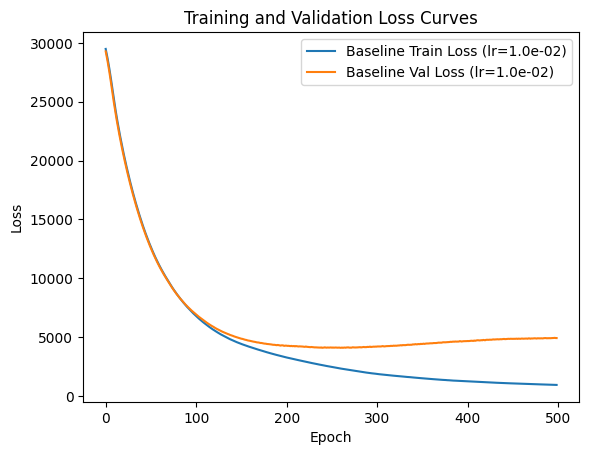

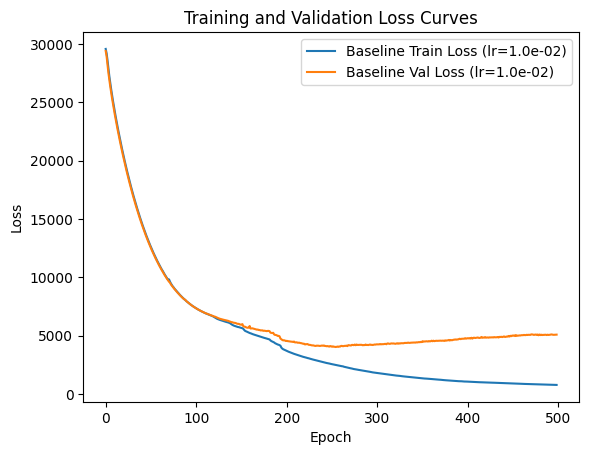

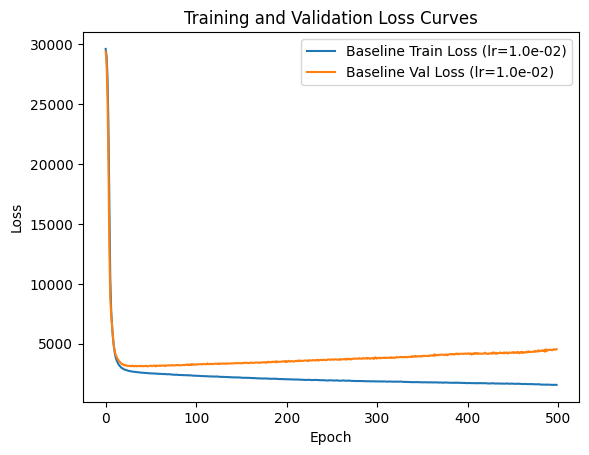

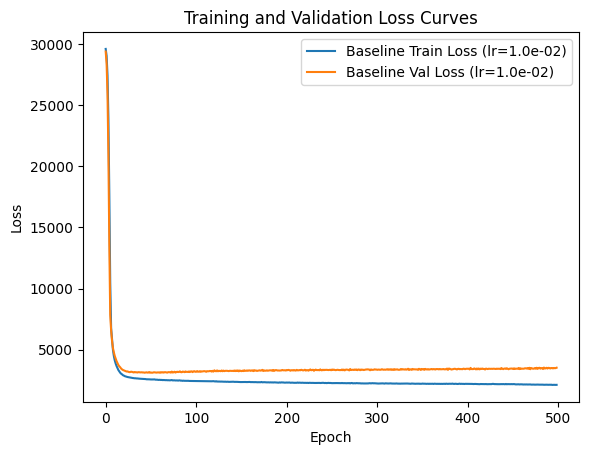

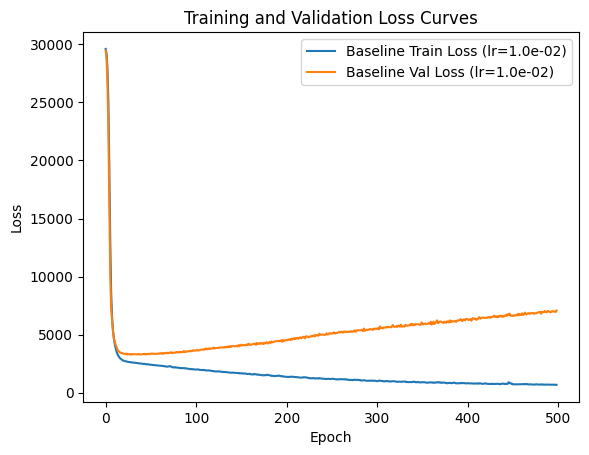

In [17]:
plot_loss_curve(sig)
plot_loss_curve(tanh)
plot_loss_curve(baseline2)
plot_loss_curve(lea)
plot_loss_curve(swi)

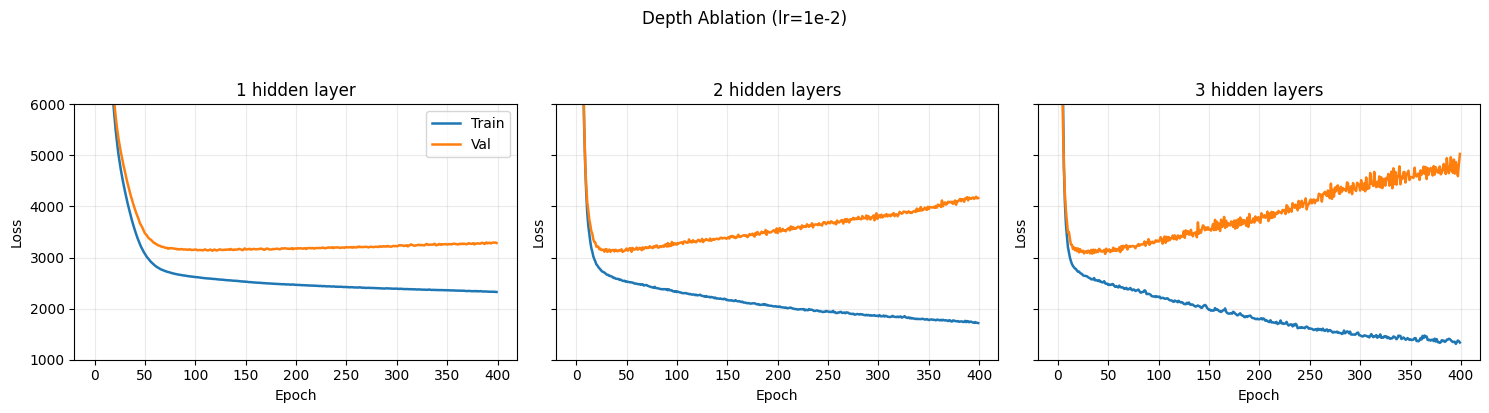

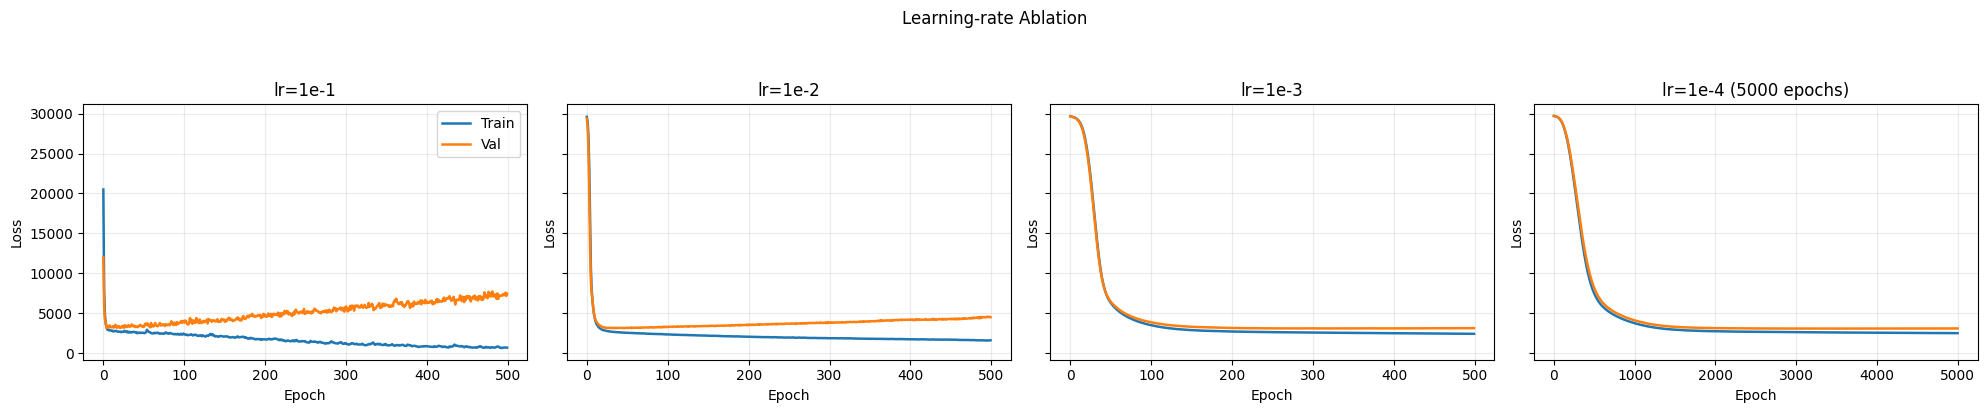

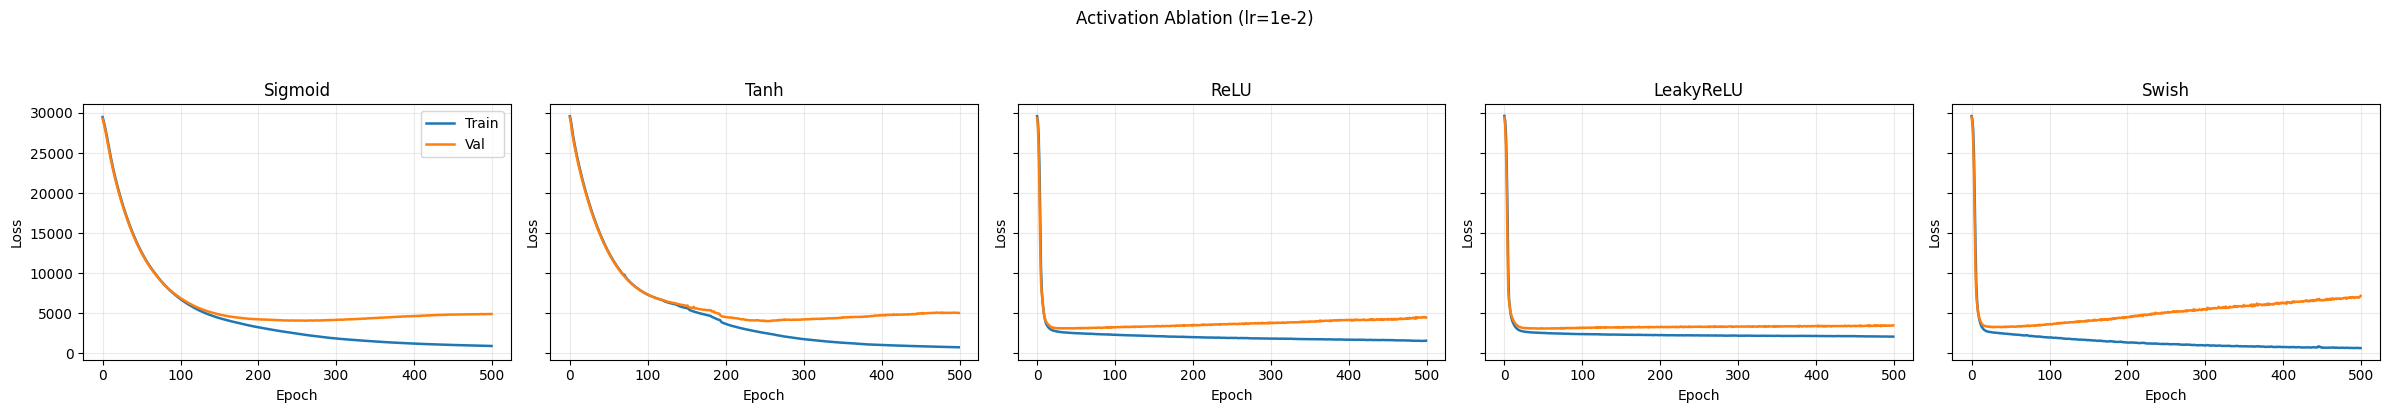

Saved figures:
- figures/depth_ablation_horizontal.png
- figures/lr_ablation_horizontal.png
- figures/activation_ablation_horizontal.png


In [18]:
import os
import matplotlib.pyplot as plt

os.makedirs('figures', exist_ok=True)

def plot_pair(ax, model, title, start=0, end=None, y_range=None):
    train = model['train_losses'][start:end]
    val = model['val_losses'][start:end]
    ax.plot(train, label='Train', linewidth=1.8)
    ax.plot(val, label='Val', linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    if y_range is not None:
        ax.set_ylim(y_range)
    ax.grid(alpha=0.25)

# 1) 深度对比（横向 3 图）
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
plot_pair(axes[0], shallow, '1 hidden layer', end=400, y_range=(1000, 6000))
plot_pair(axes[1], baseline2, '2 hidden layers', end=400, y_range=(1000, 6000))
plot_pair(axes[2], deep, '3 hidden layers', end=400, y_range=(1000, 6000))
axes[0].legend(loc='upper right', frameon=True)
fig.suptitle('Depth Ablation (lr=1e-2)', y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('figures/depth_ablation_horizontal.png', dpi=180, bbox_inches='tight')
plt.show()

# 2) 学习率对比（横向 4 图）
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
plot_pair(axes[0], lr1, 'lr=1e-1')
plot_pair(axes[1], baseline2, 'lr=1e-2')
plot_pair(axes[2], baseline, 'lr=1e-3')
plot_pair(axes[3], lr4, 'lr=1e-4 (5000 epochs)')
axes[0].legend(loc='upper right', frameon=True)
fig.suptitle('Learning-rate Ablation', y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('figures/lr_ablation_horizontal.png', dpi=180, bbox_inches='tight')
plt.show()

# 3) 激活函数对比（横向 5 图）
fig, axes = plt.subplots(1, 5, figsize=(24, 4), sharey=True)
plot_pair(axes[0], sig, 'Sigmoid')
plot_pair(axes[1], tanh, 'Tanh')
plot_pair(axes[2], baseline2, 'ReLU')
plot_pair(axes[3], lea, 'LeakyReLU')
plot_pair(axes[4], swi, 'Swish')
axes[0].legend(loc='upper right', frameon=True)
fig.suptitle('Activation Ablation (lr=1e-2)', y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('figures/activation_ablation_horizontal.png', dpi=180, bbox_inches='tight')
plt.show()

print('Saved figures:')
print('- figures/depth_ablation_horizontal.png')
print('- figures/lr_ablation_horizontal.png')
print('- figures/activation_ablation_horizontal.png')

In [22]:
# 最终结果，baseline 在测试集上的表现

print("\n=== Final Evaluation on Test Set (Baseline Model) ===")
final_model = mlp.MultiLayerPerceptron(
    in_channels=10,
    out_channels=1,
    num_hidden_layers=2,
    hidden_layer_sizes=[16, 16],
    activation='relu',
)
optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
mlp.train_model(
    model=final_model,
    optimizer=optimizer,
    criterion=criterion,
    X_train=X_train,
    y_train=y_train,
    num_epochs=baseline['best_epoch'] + 1,  # 使用之前找到的最佳 epoch 数
    batch_size=32,
    show_progress=True,
)
final_model.eval()
with torch.no_grad():
    test_predictions = final_model(X_test)
    test_mse = criterion(test_predictions, y_test).item()
print(f"Test MSE: {test_mse:.2f}")


=== Final Evaluation on Test Set (Baseline Model) ===


Epoch:   0%|          | 0/281 [00:00<?, ?it/s]

Batch 1/281:   0%|          | 0/12 [00:00<?, ?it/s]

Batch 2/281:   0%|          | 0/12 [00:00<?, ?it/s]

Batch 3/281:   0%|          | 0/12 [00:00<?, ?it/s]

...

Batch 278/281:   0%|          | 0/12 [00:00<?, ?it/s]

Batch 279/281:   0%|          | 0/12 [00:00<?, ?it/s]

Batch 280/281:   0%|          | 0/12 [00:00<?, ?it/s]

Batch 281/281:   0%|          | 0/12 [00:00<?, ?it/s]

Test MSE: 2753.92
